In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.api import OLS
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
X,y = load_diabetes(return_X_y = True)

In [4]:
lr = LinearRegression()
lr.fit(X,y)
y_pred = lr.predict(X)

In [5]:
residual = y - y_pred

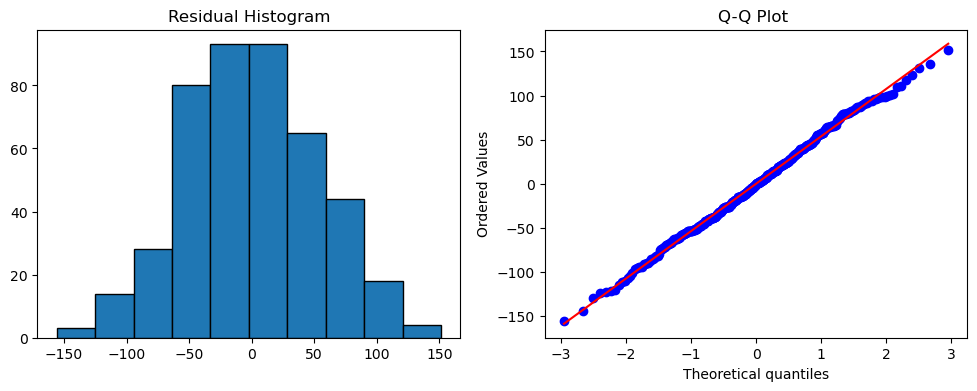

In [ ]:
# Plotting QQ Plot and Histogram
from scipy import stats
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(residual, bins=10, edgecolor='black'); axes[0].set_title("Residual Histogram")
stats.probplot(residual, plot=axes[1]); axes[1].set_title("Q-Q Plot ")
plt.show()

`This shows that residuals is normally distributed`

In [ ]:
# Applying Tests to confirm this
statistic , p = stats.shapiro(residual)
print(f"statistic -> {statistic}\np value -> {p}")
print('\n')
print(f"Mean of Residuals -> {np.mean(residual):.4f}") # Shows that mean is zero

statistic -> 0.9970648033327683
p value -> 0.6161820926788436


Mean of Residuals -> -0.0000


`We see that p value > 0.05 Cannot reject the Null Hypothesis -> The Residuals is Normally distributed`

#### Checking Normality of Residuals On custom curated data

Shapiro-Wilk: stat=0.8933, p-value=0.0058


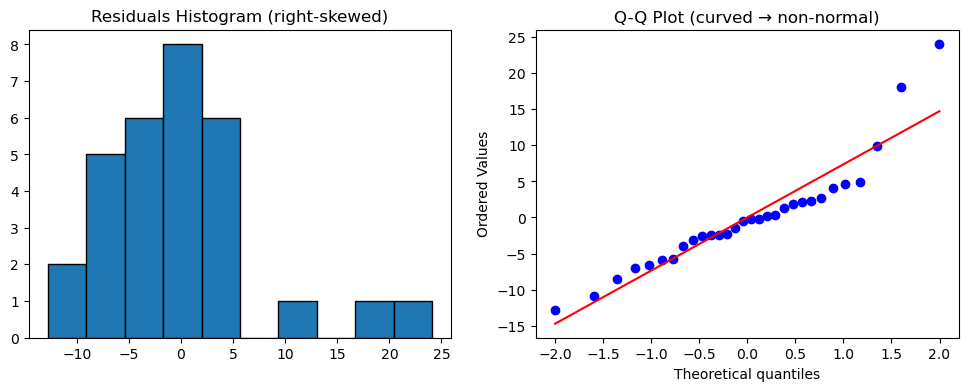

Skewness: 1.300
Kurtosis: 2.541


In [21]:
# Making a sample data where the asssumptions of Linearity is Not fulfilled
from scipy import stats

data = {
    'Age':        [25,28,30,32,35,27,40,45,50,55,60,29,33,38,42,48,52,26,31,36,41,46,53,58,24,34,39,44,49,62],
    'Experience': [1,3,5,6,8,2,12,18,22,28,32,4,7,10,14,20,25,1,5,9,13,19,26,30,0,7,11,16,21,35],
    'Hours':      [40,42,45,38,40,50,45,50,48,45,40,41,43,44,46,47,44,38,40,42,45,48,46,42,35,41,43,47,49,38],
    'Salary':     [32.1,38.5,45.2,48.9,55.4,41.0,72.3,95.6,120.8,158.4,205.7,40.2,50.1,62.8,
                   80.5,108.9,140.2,30.5,44.0,58.3,76.4,102.1,148.7,185.3,28.0,51.6,65.9,88.7,115.4,240.5]
}
df = pd.DataFrame(data)

X = df[['Age','Experience','Hours']]
y = df['Salary']

model = LinearRegression().fit(X, y)
residuals = y - model.predict(X)

# 1) Shapiro-Wilk test (H0: residuals are normal)
stat, p = stats.shapiro(residuals)
print(f"Shapiro-Wilk: stat={stat:.4f}, p-value={p:.4f}")
# p < 0.05 → reject normality ✅

# 2) Visualize
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(residuals, bins=10, edgecolor='black'); axes[0].set_title("Residuals Histogram (right-skewed)")
stats.probplot(residuals, plot=axes[1]); axes[1].set_title("Q-Q Plot (curved → non-normal)")
plt.show()

print(f"Skewness: {stats.skew(residuals):.3f}")   # should be > 1 (highly skewed)
print(f"Kurtosis: {stats.kurtosis(residuals):.3f}")# should be > 3 (heavy tails)

In [ ]:
print(f"Mean of Residuals -> {np.mean(residual):.4f}") # Shows that mean is zero but still it is not sufficient 

Mean of Residuals -> -0.0000


`This shows that the residuals is not normally distributed`

`Checking the linearity of each feature`

In [23]:
model = OLS(y,X)

In [26]:
result = model.fit()

In [28]:
print(result.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.988
Model:                            OLS   Adj. R-squared (uncentered):              0.987
Method:                 Least Squares   F-statistic:                              765.7
Date:                Fri, 08 May 2026   Prob (F-statistic):                    3.20e-26
Time:                        13:34:46   Log-Likelihood:                         -114.86
No. Observations:                  30   AIC:                                      235.7
Df Residuals:                      27   BIC:                                      239.9
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

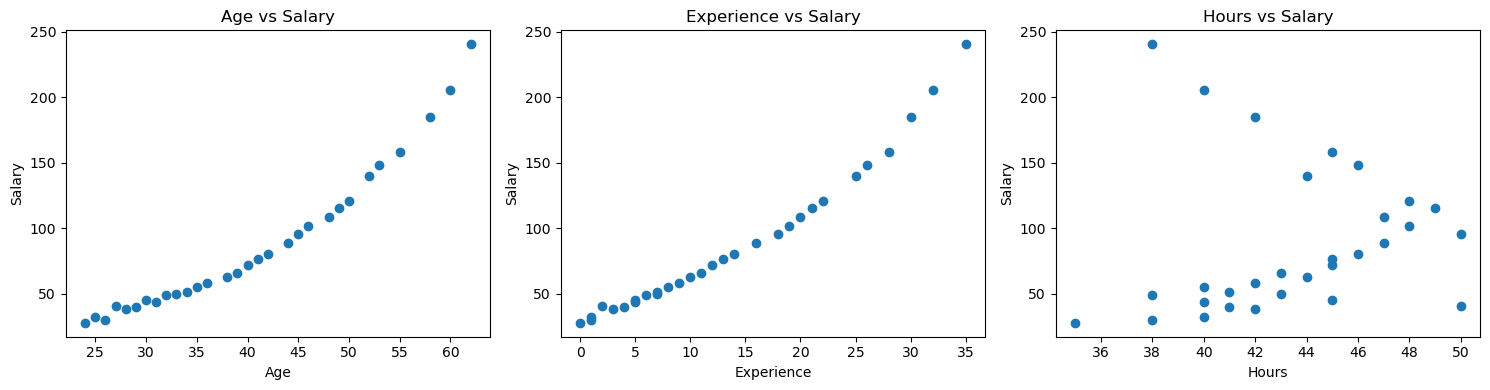

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))   # ✅ correct

for i, col in enumerate(X.columns):
    ax[i].scatter(df[col], y)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Salary')
    ax[i].set_title(f'{col} vs Salary')

plt.tight_layout()
plt.show()